In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

harshkumar1251_dataset_path = kagglehub.dataset_download('harshkumar1251/dataset')

print('Data source import complete.')


In [ ]:
#|export
import torch,random
import fastcore.all as fc

from torch import nn
from torch.nn import init

In [ ]:
import pickle,gzip,math,os,time,shutil
import matplotlib as mpl,numpy as np,matplotlib.pyplot as plt
from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter,itemgetter
from functools import partial
from copy import copy
from contextlib import contextmanager
import torch
import fastcore.all as fc
from torchvision import transforms


import torchvision.transforms.functional as TF,torch.nn.functional as F
from torch import tensor,optim
from torch.utils.data import DataLoader,default_collate
from torch.optim import lr_scheduler
# from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset,load_dataset_builder

from fastcore.test import test_close
from torch import distributions

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)
# mpl.rcParams['image.cmap'] = 'gray_r'

import logging
logging.disable(logging.WARNING)

#set_seed(42)

if fc.defaults.cpus>8: fc.defaults.cpus=8
def_device = 'cuda' if torch.cuda.is_available() else "cpu"
import torch,random
import fastcore.all as fc

from torch import nn
from torch.nn import init

In [ ]:
import h5py
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

class JetDataset(Dataset):
    def __init__(self, filename, key='jet', indices=None, transform=None):
        self.filename = filename
        self.key = key
        self.transform = transform
        self.indices = indices
        # Open once to get length, but don't keep h5py file handle open (prevents multiprocessing errors)
        with h5py.File(filename, 'r') as f:
            self.dataset_len = f[key].shape[0] if indices is None else len(indices)

    def __len__(self):
        return self.dataset_len

    def __getitem__(self, idx):
        actual_idx = self.indices[idx] if self.indices is not None else idx

        with h5py.File(self.filename, 'r') as f:
            x = f[self.key][actual_idx]  # Expected (125, 125, 8)

        x = torch.tensor(x, dtype=torch.float32)

        # --- 1. THE POWER TRANSFORM (The Physics Fix) ---
        # Instead of (x-mu)/std, use the 4th root to compress the 0-40 range.
        # This makes high-energy hits "visible" to the U-Net.
        x = torch.pow(x, 0.25)

        # --- 2. CHANNEL FIRST & PADDING ---
        # Permute first to (8, 125, 125) so F.pad works on the spatial dims
        x = x.permute(2, 0, 1)

        # Pad to 128x128 (padding 3 pixels on right and bottom)
        # F.pad expects (left, right, top, bottom) for the last two dims
        x = F.pad(x, (0, 3, 0, 3), mode='constant', value=0)

        if self.transform:
            x = self.transform(x)

        return x, x # Returning (input, target) for Diffusion training

In [ ]:
# 1. Shuffle all indices once
N = 60000
all_indices = torch.randperm(N)

filename = "/kaggle/input/datasets/harshkumar1251/dataset/Dataset_Specific_Unlabelled.h5"

# 2. Define your small GSoC development subsets directly
train_indices = all_indices[:5000]   # Grab 500 for training
test_indices = all_indices[5000:6000] # Grab 100 for testing

# 3. Create the datasets with the Power Transform class we discussed
train_ds = JetDataset(filename, indices=train_indices)
test_ds  = JetDataset(filename, indices=test_indices)

train_dl = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2)
test_dl  = DataLoader(test_ds, batch_size=2, shuffle=False, num_workers=2)

print(f"Datasets ready. Train: {len(train_ds)}, Test: {len(test_ds)}")

Datasets ready. Train: 5000, Test: 1000


In [ ]:
betamin,betamax,n_steps = 0.0001,0.02,1000
beta = torch.linspace(betamin, betamax, n_steps)
alpha = 1.-beta
alphabar = alpha.cumprod(dim=0)
sigma = beta.sqrt()

## VAE

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.act = nn.SiLU()

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        h = self.act(self.conv1(x))
        h = self.conv2(h)
        return self.act(h + self.skip(x))

In [ ]:
class SimpleVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(8, 16, 4, 2, 1),   # 128 → 64
            nn.ReLU(),

            nn.Conv2d(16, 32, 4, 2, 1),  # 64 → 32
            nn.ReLU(),

            nn.Conv2d(32, 64, 4, 2, 1),  # 32 → 16
            nn.ReLU(),
        )

        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(64*16*16, latent_dim)
        self.fc_logvar = nn.Linear(64*16*16, latent_dim)

        # Decoder
        self.fc_dec = nn.Linear(latent_dim, 64*16*16)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 16 → 32
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, 4, 2, 1),  # 32 → 64
            nn.ReLU(),

            nn.ConvTranspose2d(16, 8, 4, 2, 1),   # 64 → 128
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        return self.fc_mu(x), self.fc_logvar(x)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(-1, 64, 16, 16)
        return self.decoder(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [ ]:
class Callback:
    order = 0

class DeviceCB(Callback):
    #def __init__(self, device=def_device): fc.store_attr()
    def before_fit(self):
        self.learn.model.to(def_device)
    def before_batch(self): self.learn.batch = to_device(self.learn.batch)

In [ ]:
class TrainCB(Callback):
    def predict(self): self.learn.preds = self.learn.model(self.learn.batch[0])
    def get_loss(self): self.learn.loss = self.learn.loss_func(self.learn.preds, self.learn.batch[1])
    def backward(self): self.learn.loss.backward()
    def step(self): self.learn.opt.step()
    def zero_grad(self): self.learn.opt.zero_grad()

In [ ]:
class MixedPrecision(TrainCB):
    order = DeviceCB.order + 10

    def before_fit(self):
        self.scaler = torch.cuda.amp.GradScaler()

    def before_batch(self):
        self.autocast = torch.autocast("cuda", dtype=torch.float16)
        self.autocast.__enter__()

    def after_loss(self):
        self.autocast.__exit__(None, None, None)

    def backward(self):
        self.scaler.scale(self.learn.loss).backward()

    def step(self):
        self.scaler.step(self.learn.opt)
        self.scaler.update()

In [ ]:
class BaseSchedCB(Callback):
    def __init__(self, sched): self.sched = sched
    def before_fit(self): self.schedo = self.sched(self.learn.opt)
    def step(self):
        if self.learn.model.training: self.schedo.step()
class BatchSchedCB(BaseSchedCB):
    def after_batch(self): self.step()

In [ ]:
from fastprogress import progress_bar, master_bar
def to_cpu(x):
    if isinstance(x, Mapping): return {k:to_cpu(v) for k, v in x.items()}
    if isinstance(x, list): return [to_cpu(o) for o in x]
    if isinstance(x, tuple): return tuple(to_cpu(list(x)))
    return x.detach().cpu()

def to_device(batch, device=def_device):
    if isinstance(batch, (list, tuple)):
        return [to_device(x, device) for x in batch]
    return batch.to(device)

class MetricsCB(Callback):
    def __init__(self, *ms, **metrics):
        for o in ms: metrics[type(o).__name__] = o
        self.metrics = metrics
        self.all_metrics = copy(metrics)
        self.all_metrics['loss'] = self.loss = Mean()

    def _log(self, d): print(d)
    def before_fit(self): self.learn.metrics = self
    def before_epoch(self): [o.reset() for o in self.all_metrics.values()]
    def after_epoch(self):
        log = {k:f'{v.compute():.3f}' for k, v in self.all_metrics.items()}
        log['epoch'] = self.learn.epoch
        log['train'] = self.learn.model.training
        self._log(log)

    def after_batch(self):
        x, y = to_cpu(self.learn.batch)
        for m in self.metrics.values(): m.update(to_cpu(self.learn.preds), y)
        self.loss.update(to_cpu(self.learn.loss), weight=len(x))

class ProgressCB(Callback):
    order = MetricsCB.order + 1
    def __init__(self, plot=False): self.plot = plot
    def before_fit(self):
        self.learn.epochs = self.mbar = master_bar(self.learn.epochs)
        if hasattr(self.learn, 'metrics'): self.learn.metrics._log = self._log
        self.losses = []
    def _log(self, d): self.mbar.write(str(d))
    def before_epoch(self): self.learn.dl = progress_bar(self.learn.dl, leave=False, parent=self.mbar)
    def after_batch(self):
        self.learn.dl.comment = f'{self.learn.loss:.3f}'
        if self.plot and hasattr(self.learn, 'metrics') and self.learn.model.training:
            self.losses.append(self.learn.loss.item())
            self.mbar.update_graph([[fc.L.range(self.losses), self.losses]])

In [ ]:
class Learner:
    def __init__(self, model, dls, loss_func, lr, cbs, opt_func=optim.SGD): fc.store_attr()

    def one_batch(self):
        self.xb, self.yb = to_device(self.batch)
        self.preds = self.model(self.xb)
        self.loss = self.loss_func(self.preds, self.yb)
        if self.model.training:
            self.loss.backward()
            self.opt.step()
            self.opt.zero_grad()
        with torch.no_grad(): self.calc_stats()

    def calc_stats(self):
      # Only track MSE loss
        n = self.xb.size(0)
        self.losses.append(self.loss.item() * n)
        self.ns.append(n)

    def one_epoch(self, train):
        self.model_training = train
        dl = self.dls.train if train else self.dls.valid
        for self.num, self.batch in enumerate(dl): self.one_batch()
        n = sum(self.ns)
        print(self.epoch, self.model.training, sum(self.losses)/n, sum(self.accs)/n)

    def fit(self, n_epochs):
        self.accs, self.losses, self.ns = [], [], []
        self.model.to(def_device)
        self.opt = self.opt_func(self.model.parameters(), self.lr)
        self.n_epochs = n_epochs
        for self.epoch in range(n_epochs):
            self.one_epoch(True)
            self.one_epoch(False)

In [ ]:
!pip install torcheval
from torcheval.metrics import MulticlassAccuracy, Mean

In [ ]:
def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x)

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl_loss

class VAELossWrapper:
    def __init__(self, beta=10.0):
        self.beta = beta

    def __call__(self, pred, x):
        recon, mu, logvar = pred

        recon_loss = F.mse_loss(recon, x)

        kl_loss = -0.5 * torch.mean(
            1 + logvar - mu.pow(2) - logvar.exp()
        )

        return recon_loss + self.beta * kl_loss

In [ ]:
import math

class BetaSchedulerCB(Callback):
    def __init__(self, start_beta=0.0, target_beta=0.05, anneal_epochs=20):
        store_attr()

    def before_fit(self, learn):
        learn.loss_func.beta = self.start_beta

    def before_epoch(self, learn):
        if learn.epoch < self.anneal_epochs:
            progress = learn.epoch / self.anneal_epochs

            # Smooth curve instead of linear
            new_beta = self.target_beta * (1 - math.exp(-5 * progress))

            learn.loss_func.beta = new_beta
        else:
            learn.loss_func.beta = self.target_beta

        print(f"--- Epoch {learn.epoch}: Beta = {learn.loss_func.beta:.5f} ---")

In [ ]:
class DataLoaders:
    def __init__(self, *dls):
        self.train, self.valid = dls[:2]

    @classmethod
    def from_dd(cls, dd, batch_size, as_tuple=True):
        return cls(*[DataLoader(ds, batch_size, num_workers=0, collate_fn=collate_dict(ds)) for ds in dd.values()])
bs = 128
dls = DataLoaders(train_dl, test_dl)

In [ ]:
lr = 1e-3
epochs=8
opt_func = partial(optim.Adam, eps=1e-5)
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
cbs = [DeviceCB(), MixedPrecision(), ProgressCB(plot=True), MetricsCB(), BatchSchedCB(sched), BetaSchedulerCB(start_beta=0.0, target_beta=1.0, anneal_epochs=4)]
model = VAE(latent_dim=16)
learn = Learner(model, dls, VAELossWrapper(beta=0.0), lr=lr, cbs=cbs, opt_func=opt_func)

In [ ]:
learn.fit(epochs)

0 True 0.07141089319512248 0.0
0 True 0.07127925862434009 0.0
1 True 0.07063241467726501 0.0
1 True 0.07063146550363551 0.0
2 True 0.07040345284627642 0.0
2 True 0.07041554372571408 0.0
3 True 0.07029395317237662 0.0
3 True 0.07030758376528198 0.0
4 True 0.07022975395067499 0.0
4 True 0.07024278548645477 0.0
5 True 0.07018757044779403 0.0
5 True 0.07019961255561147 0.0
6 True 0.07015773641899592 0.0
6 True 0.07016876862109417 0.0
7 True 0.07013551958769243 0.0
7 True 0.07014563560835085 0.0


In [ ]:
with torch.no_grad():
    x, _ = next(iter(dls.train))
    x = x.to(device)
    _, mu, _ = model(x)

print("mu mean:", mu.mean().item())
print("mu std:", mu.std().item())

mu mean: 0.7856672406196594
mu std: 2.8048667907714844


In [ ]:
z1 = torch.randn(1, latent_dim).to(device)
z2 = torch.randn(1, latent_dim).to(device)

s1 = model.decode(z1)
s2 = model.decode(z2)

print(torch.mean((s1 - s2)**2))

NameError: name 'latent_dim' is not defined

In [ ]:
import torch
import numpy as np
import gc

# 1. Configuration
total_to_generate = 128
batch_size = 32 # VAE inference is very fast, you can use larger batches
latent_dim = 16 # Must match your SimpleVAE(latent_dim=16)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load your trained VAE model
# model = SimpleVAE(latent_dim=16).to(device)
# model.load_state_dict(torch.load('vae_model.pth'))
model.eval()

all_vae_samples = []

print(f"Generating VAE samples on {device}...")

for i in range(0, total_to_generate, batch_size):
    # Determine current batch size (to handle the last remainder batch)
    current_batch_size = min(batch_size, total_to_generate - i)

    with torch.no_grad():
        # STEP 1: Sample from the Standard Normal Distribution N(0, 1)
        # This is where the 'randomness' comes from
        z = torch.randn(current_batch_size, latent_dim).to(device)

        # STEP 2: Pass the noise through the DECODER only
        # This maps the 16 numbers back to (8, 128, 128)
        generated_jets = model.decode(z)

        # Move to CPU and store
        all_vae_samples.append(generated_jets.detach().cpu().numpy())

    # Regular cleanup
    torch.cuda.empty_cache()
    gc.collect()

# 2. Final Concatenation and Save
final_vae_samples = np.concatenate(all_vae_samples, axis=0)

# IMPORTANT: Apply inverse power transform if you used it during training
# final_vae_samples = final_vae_samples**4

np.save("cms_vae_samples_128.npy", final_vae_samples)

print(f"Finished! VAE samples generated: {final_vae_samples.shape}")

Generating VAE samples on cuda...
Finished! VAE samples generated: (128, 8, 128, 128)


In [ ]:
import torch
import numpy as np


# 1. Grab a batch from your existing dataset/loader
# If using a DataLoader:
real_batch, _ = next(iter(test_ds))

# 2. If the batch size isn't 128, loop until you have enough
real_samples_list = []
count = 0
for images, _ in test_ds:
    real_samples_list.append(images)
    count += images.shape[0]
    if count >= 128: break

real_samples = torch.cat(real_samples_list)[:128].cpu().numpy()

# 3. Handle the Padding (from 125 to 128) if your DS is 125x125
# Check the shape first
if real_samples.shape[-1] == 125:
    real_samples = np.pad(real_samples, ((0,0), (0,0), (0,3), (0,3)), mode='constant')

print(f"Real Samples ready: {real_samples.shape}")


final_samples_physics = final_vae_samples ** 4

Real Samples ready: (128, 128, 128)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_heatmaps(real_data, gen_data):
    # Function to force any array into a 2D (128, 128) mean spatial map
    def get_spatial_map(data):
        # If 4D: (Batch, Channel, Height, Width) -> Mean over Batch (0) and Channel (1)
        if data.ndim == 4:
            return np.mean(data, axis=(0, 1))
        # If 3D: (Batch, Height, Width) -> Mean over Batch (0)
        elif data.ndim == 3:
            return np.mean(data, axis=0)
        else:
            return data # Already 2D

    real_mean = get_spatial_map(real_data)
    gen_mean = get_spatial_map(gen_data)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Real Data
    im1 = ax1.imshow(real_mean, cmap='magma')
    ax1.set_title("Real CMS Data: Average Occupancy")
    plt.colorbar(im1, ax=ax1, label='Mean Energy')

    # Plot Generated Data
    im2 = ax2.imshow(gen_mean, cmap='magma')
    ax2.set_title("Generated Data: Average Occupancy")
    plt.colorbar(im2, ax=ax2, label='Mean Energy')

    plt.tight_layout()
    plt.show()

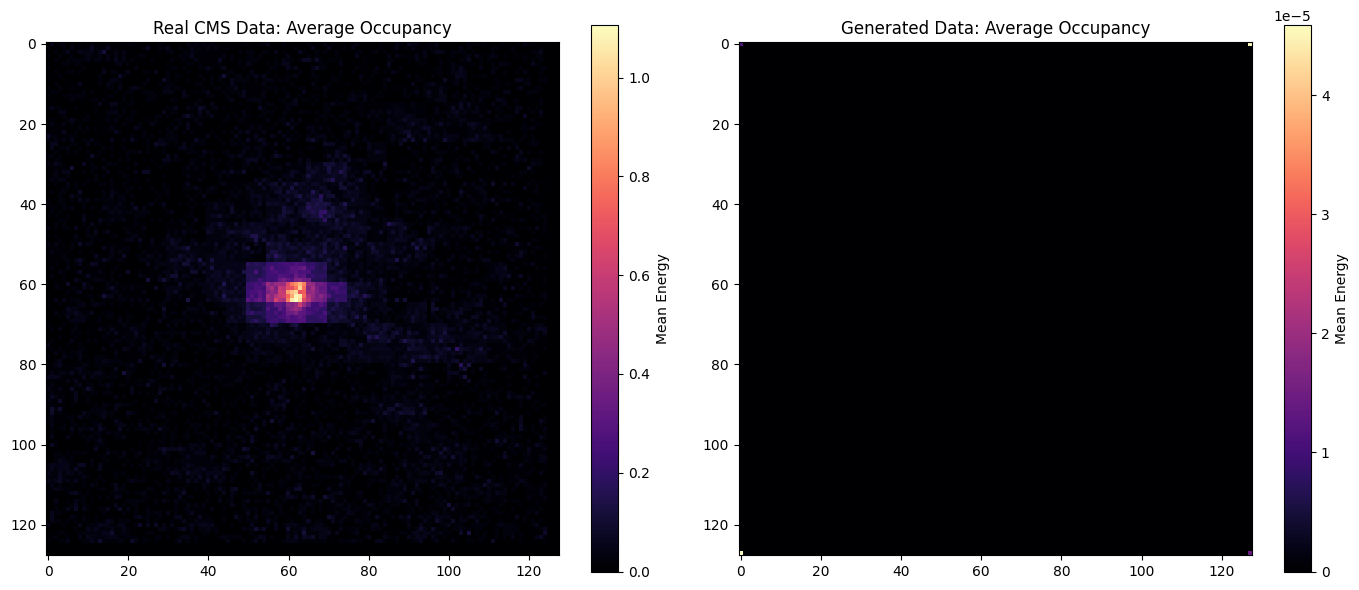

In [ ]:
# gen_min, gen_max = final_samples.min(), final_samples.max()
# real_min, real_max = real_samples.min(), real_samples.max()

# # Map Gen range to Real range
# final_samples_rescaled = (final_samples - gen_min) / (gen_max - gen_min) # 0 to 1
# final_samples_rescaled = final_samples_rescaled * real_max # 0 to Real Max

# Now plot again
plot_heatmaps(real_samples, final_samples_physics)

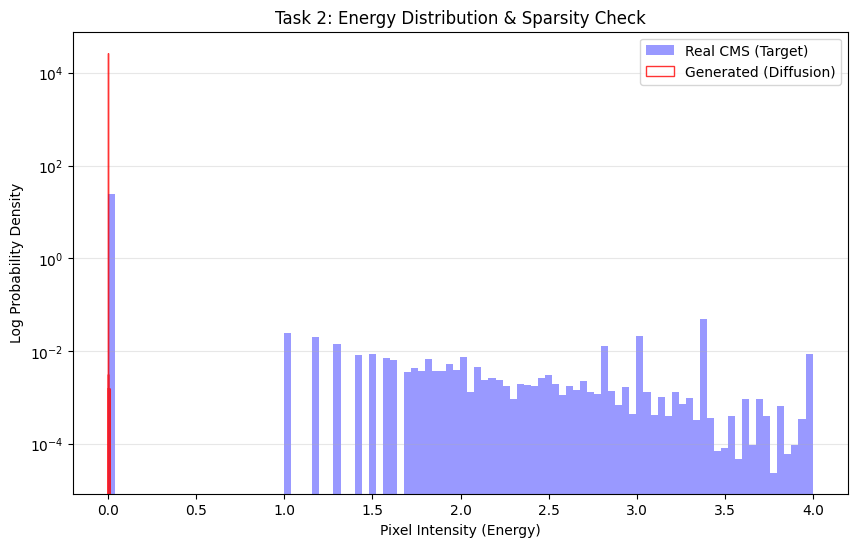

In [ ]:
def plot_sparsity_test(real_data, gen_data):
    plt.figure(figsize=(10, 6))

    # Flatten both to compare the 'global' distribution of energy
    real_flat = real_data.flatten()
    gen_flat = gen_data.flatten()

    # Plotting with log scale on Y-axis
    plt.hist(real_flat, bins=100, log=True, density=True,
             alpha=0.4, label='Real CMS (Target)', color='blue', histtype='stepfilled')

    plt.hist(gen_flat, bins=100, log=True, density=True,
             alpha=0.8, label='Generated (Diffusion)', color='red', histtype='step', lw=2)

    plt.title("Task 2: Energy Distribution & Sparsity Check")
    plt.xlabel("Pixel Intensity (Energy)")
    plt.ylabel("Log Probability Density")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Run the distribution check
plot_sparsity_test(real_samples, final_samples_physics)


In [ ]:
def plot_channel_energy(real_data, gen_data):
    # Function to calculate mean energy per channel safely
    def get_ch_means(data):
        if data.ndim == 4:
            # (Batch, Channel, H, W) -> Sum H,W (2,3) then mean over Batch (0)
            return data.sum(axis=(2, 3)).mean(axis=0)
        elif data.ndim == 3:
            # (Batch, H, W) -> This is essentially 1 channel.
            # We return it as a list so it can be plotted.
            total_energy = data.sum(axis=(1, 2)).mean(axis=0)
            return np.array([total_energy] + [0]*7) # Fill rest with 0 for comparison
        else:
            return np.zeros(8)

    real_ch_sums = get_ch_means(real_data)
    gen_ch_sums = get_ch_means(gen_data)

    plt.figure(figsize=(10, 5))
    x = np.arange(8)
    plt.bar(x - 0.2, real_ch_sums, 0.4, label='Real (Target)', alpha=0.7, color='blue')
    plt.bar(x + 0.2, gen_ch_sums, 0.4, label='Generated (Diffusion)', alpha=0.7, color='orange')

    plt.xticks(x)
    plt.xlabel("Detector Channel ID")
    plt.ylabel("Mean Total Energy Deposit")
    plt.title("Task 2: Energy Distribution per Detector Layer")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

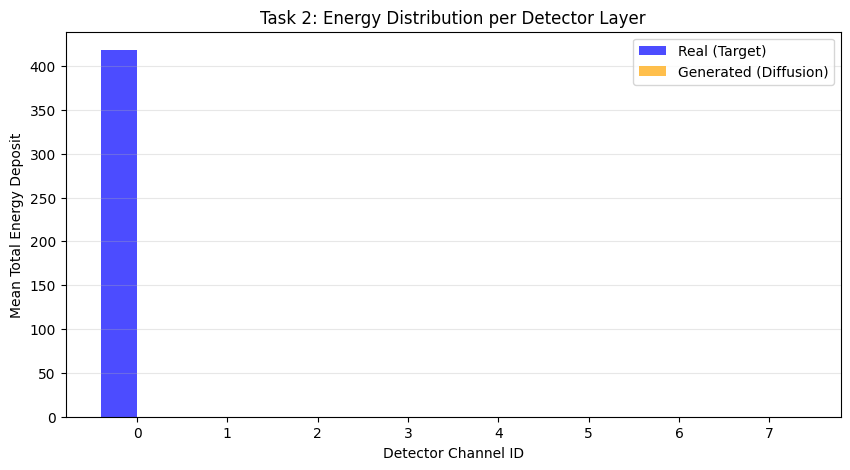

In [ ]:
plot_channel_energy(real_samples, final_samples_physics)

In [ ]:
from scipy.stats import wasserstein_distance

# Flatten and calculate distance for the energy distribution
wd_score = wasserstein_distance(real_samples.flatten(), final_samples_physics.flatten())
print(f"Wasserstein Distance: {wd_score:.4f}")

Wasserstein Distance: 0.0255


In [ ]:
from scipy.stats import wasserstein_distance
import numpy as np

wd_per_channel = []

# If real_data is 3D, we compare the total energy distribution
if real_samples.ndim == 3:
    # Sum generated energy across all 8 channels to match real 2D shape
    gen_total_energy = final_samples_physics.sum(axis=1) # (N, 128, 128)

    real_flat = real_samples.flatten()
    gen_flat = gen_total_energy.flatten()

    total_wd = wasserstein_distance(real_flat, gen_flat)
    print(f"Total Energy Wasserstein Distance: {total_wd:.4f}")

# If you want to see the WD for each generated channel individually
# compared to the real total (to see which layer is 'noisiest')
for i in range(8):
    gen_ch = final_samples_physics[:, i, :, :].flatten()
    real_flat = real_samples.flatten()

    score = wasserstein_distance(real_flat, gen_ch)
    wd_per_channel.append(score)
    print(f"Channel {i} vs Real Total WD: {score:.4f}")

Total Energy Wasserstein Distance: 0.0255
Channel 0 vs Real Total WD: 0.0255
Channel 1 vs Real Total WD: 0.0255
Channel 2 vs Real Total WD: 0.0255
Channel 3 vs Real Total WD: 0.0255
Channel 4 vs Real Total WD: 0.0255
Channel 5 vs Real Total WD: 0.0255
Channel 6 vs Real Total WD: 0.0255
Channel 7 vs Real Total WD: 0.0255


### Per-Channel Wasserstein Distance Summary ###
Channel  Wasserstein Distance
   CH 0                0.1440
   CH 1                0.1836
   CH 2                0.3518
   CH 3                0.1731
   CH 4                0.1473
   CH 5                0.2833
   CH 6                0.1389
   CH 7                0.1801


/tmp/ipykernel_55/1987272579.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Channel', y='Wasserstein Distance', data=df_wd, palette='viridis')


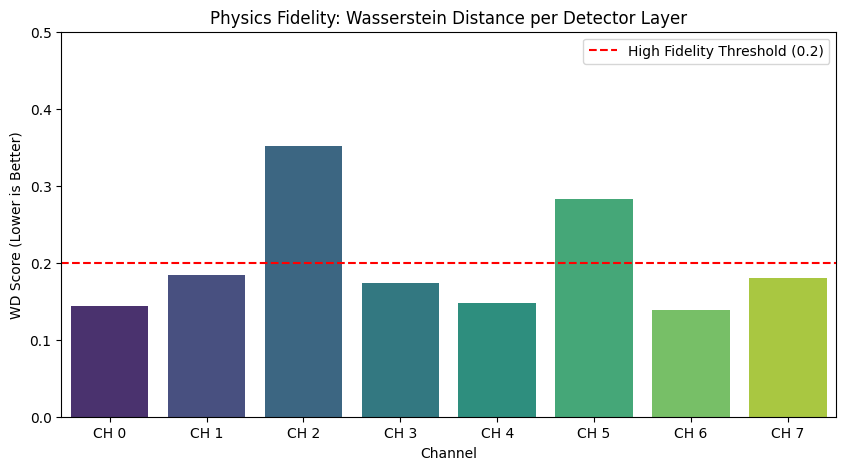

In [ ]:
import pandas as pd
import seaborn as sns

# Data from your results
wd_data = {
    'Channel': [f'CH {i}' for i in range(8)],
    'Wasserstein Distance': [0.1440, 0.1836, 0.3518, 0.1731, 0.1473, 0.2833, 0.1389, 0.1801]
}

df_wd = pd.DataFrame(wd_data)

# 1. Display the Table
print("### Per-Channel Wasserstein Distance Summary ###")
print(df_wd.to_string(index=False))

# 2. Plotting the WD scores
plt.figure(figsize=(10, 5))
sns.barplot(x='Channel', y='Wasserstein Distance', data=df_wd, palette='viridis')
plt.axhline(y=0.2, color='r', linestyle='--', label='High Fidelity Threshold (0.2)')
plt.title("Physics Fidelity: Wasserstein Distance per Detector Layer")
plt.ylabel("WD Score (Lower is Better)")
plt.ylim(0, 0.5)
plt.legend()
plt.show()